数据集形状: (26, 2)
前5个数据点:
 [[ 9.96346605  4.59676542]
 [11.0329545  -0.16816717]
 [11.54155807  5.21116083]
 [ 8.69289001  1.54322016]
 [ 8.1062269   4.28695977]]
前5个标签: [1 0 1 0 0]
标签种类: {np.int64(0), np.int64(1)}


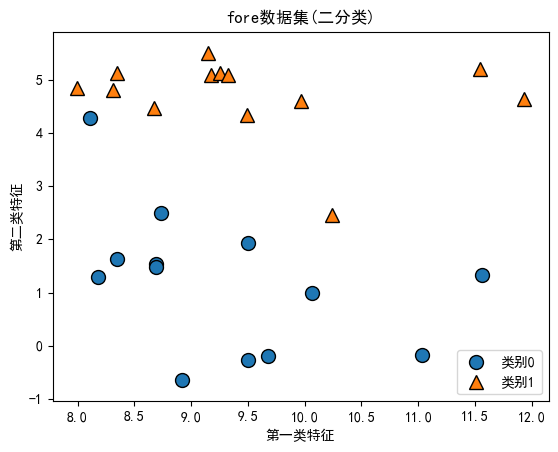

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn

plt.rcParams['font.sans-serif']=['SimHei','Microsoft YaHei','DejaVu Sans']
plt.rcParams['axes.unicode_minus']=False

X,y=mglearn.datasets.make_forge()

print("数据集形状:",X.shape)
print("前5个数据点:\n",X[:5])
print("前5个标签:",y[:5])
print("标签种类:",set(y))

mglearn.discrete_scatter(X[:,0],X[:,1],y)
plt.legend(["类别0","类别1"],loc=4)
plt.xlabel("第一类特征")
plt.ylabel("第二类特征")
plt.title("fore数据集(二分类)")
plt.show()

In [2]:
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0)

knn_1 = KNeighborsClassifier(n_neighbors=1)
knn_1.fit(X_train,y_train)

print("1个邻居模型")
print("训练集精度:{:.3f}".format(knn_1.score(X_train,y_train)))
print("测试集精度:{:.3f}".format(knn_1.score(X_test,y_test)))

1个邻居模型
训练集精度:1.000
测试集精度:0.857


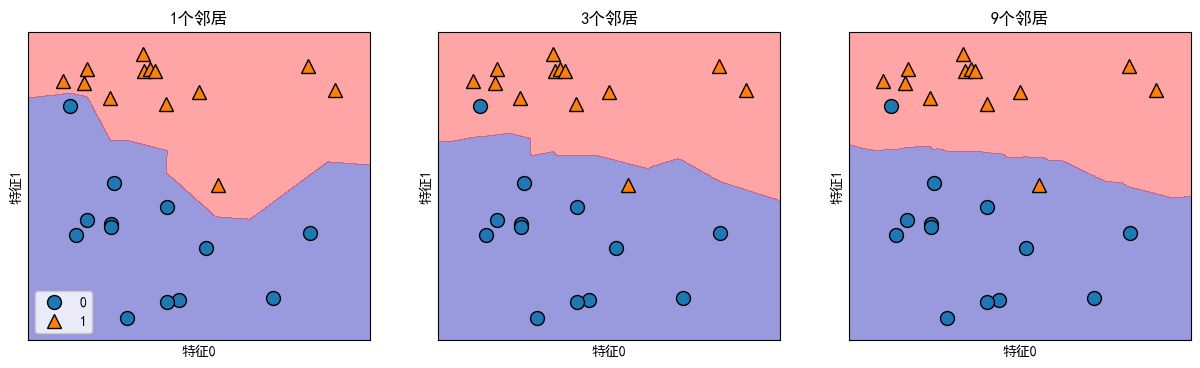

In [3]:
fig,axes=plt.subplots(1,3,figsize=(15,4))

for n_neighbors,ax in zip([1,3,9],axes):
    clf=KNeighborsClassifier(n_neighbors=n_neighbors).fit(X,y)
    mglearn.plots.plot_2d_separator(clf,X,fill=True,eps=0.5,ax=ax,alpha=0.4)
    mglearn.discrete_scatter(X[:,0],X[:,1],y,ax=ax)
    ax.set_title(f"{n_neighbors}个邻居")
    ax.set_xlabel("特征0")
    ax.set_ylabel("特征1")

axes[0].legend(loc=3)
plt.show()

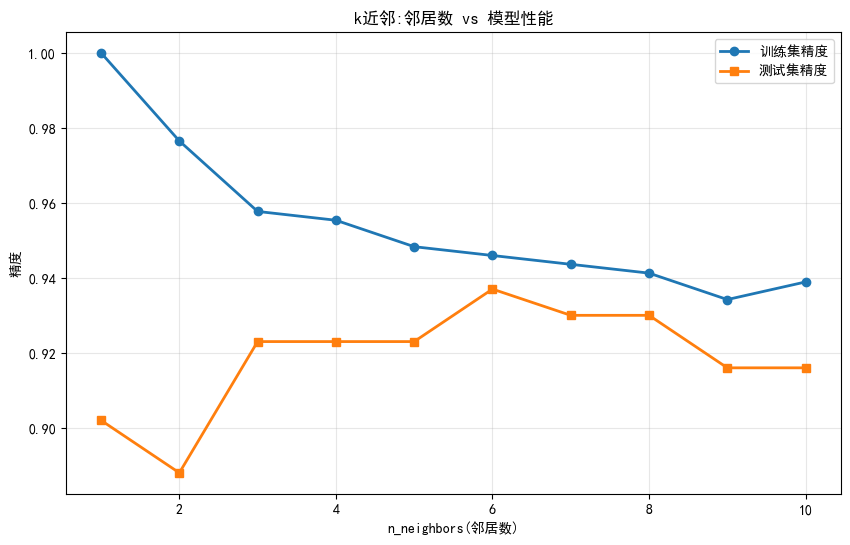

最佳邻居数:6
此时测试集精度:0.937


In [8]:
from sklearn.datasets import load_breast_cancer
cancer= load_breast_cancer()

X_train,X_test,y_train,y_test=train_test_split(
    cancer.data,cancer.target,stratify=cancer.target,random_state=66)

training_accuracy=[]
test_accuracy=[]
neighbors_settings=range(1,11)

for n_neighbors in neighbors_settings:
    clf=KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train,y_train)
    training_accuracy.append(clf.score(X_train,y_train))
    test_accuracy.append(clf.score(X_test,y_test))

plt.figure(figsize=(10,6))
plt.plot(neighbors_settings,training_accuracy,'o-',label='训练集精度',linewidth=2)
plt.plot(neighbors_settings,test_accuracy,'s-',label='测试集精度',linewidth=2)
plt.xlabel('n_neighbors(邻居数)')
plt.ylabel('精度')
plt.title('k近邻:邻居数 vs 模型性能')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

best_n = neighbors_settings[test_accuracy.index(max(test_accuracy))]
print(f"最佳邻居数:{best_n}")
print(f"此时测试集精度:{max(test_accuracy):.3f}")

In [10]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
import mglearn
import matplotlib.pyplot as plt

X,y=mglearn.datasets.make_wave(n_samples=40)

X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0)

print("数据集形状:",X.shape)
print("前5个目标值:",y[:5])

数据集形状: (40, 1)
前5个目标值: [-0.44822073  0.33122576  0.77932073  0.03497884 -1.38773632]


In [11]:
reg_1 = KNeighborsRegressor(n_neighbors=1)
reg_1.fit(X_train,y_train)

print("单一近邻回归")
print(f"训练集 R²:{reg_1.score(X_train,y_train):.3f}")
print(f"测试集 R²:{reg_1.score(X_test,y_test):.3f}")

单一近邻回归
训练集 R²:1.000
测试集 R²:0.352


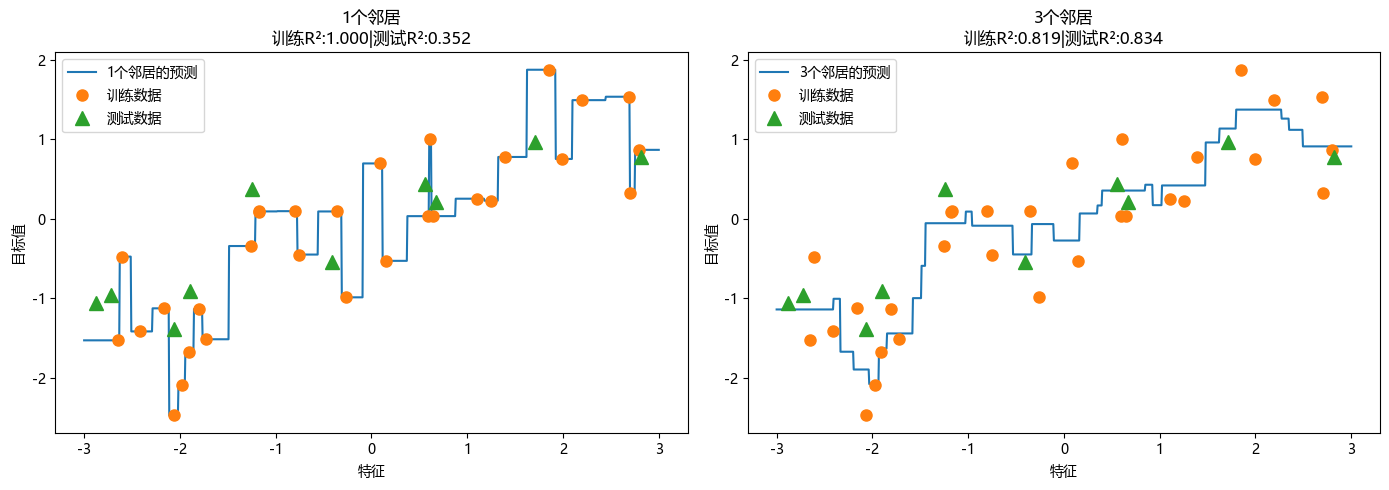

In [14]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
fig,axes=plt.subplots(1,2,figsize=(14,5))

line = np.linspace(-3,3,1000).reshape(-1,1)

for n_neighbors,ax in zip([1,3],axes):
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train,y_train)

    ax.plot(line,reg.predict(line),label=f'{n_neighbors}个邻居的预测')

    ax.plot(X_train,y_train,'o',label='训练数据',markersize=8)
    ax.plot(X_test,y_test,'^',label='测试数据',markersize=10)

    ax.set_title(f'{n_neighbors}个邻居\n训练R²:{reg.score(X_train,y_train):.3f}|测试R²:{reg.score(X_test,y_test):.3f}')
    ax.set_xlabel('特征')
    ax.set_ylabel('目标值')
    ax.legend()

plt.tight_layout()
plt.show()

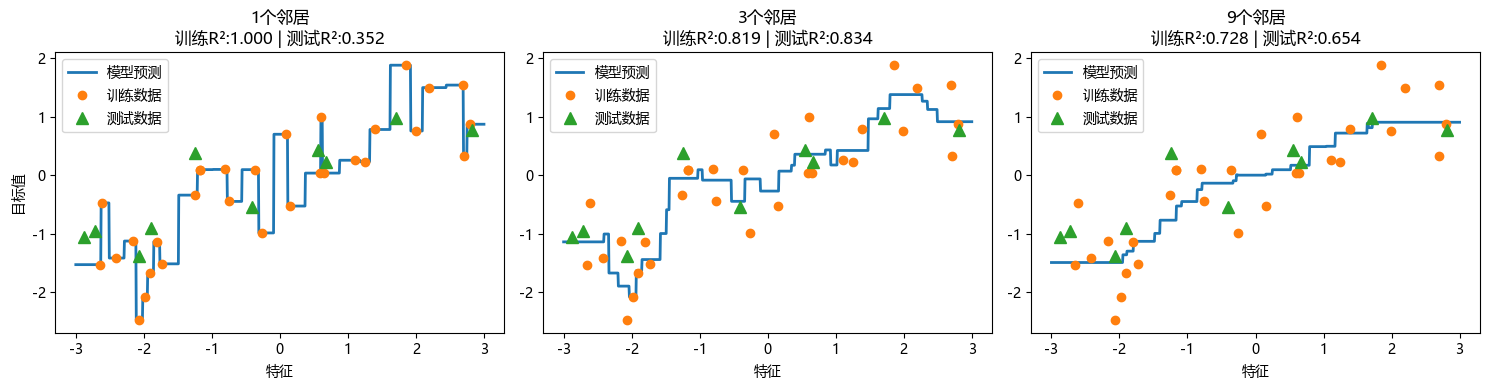

In [16]:
fig,axes = plt.subplots(1,3,figsize=(15,4))

for n_neighbors,ax in zip([1,3,9],axes):
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train,y_train)

    ax.plot(line,reg.predict(line),label='模型预测',linewidth=2)

    ax.plot(X_train,y_train,'o',label='训练数据',markersize=6)
    ax.plot(X_test,y_test,'^',label='测试数据',markersize=8)

    ax.set_title(f'{n_neighbors}个邻居\n训练R²:{reg.score(X_train,y_train):.3f} | 测试R²:{reg.score(X_test,y_test):.3f}')
    ax.set_xlabel('特征')
    ax.legend()

axes[0].set_ylabel('目标值')
plt.tight_layout()
plt.show()